# Project Milestone One: Gathering your Team, Understanding the Problem,  Exploring the Data

#### Due: Midnight on July 20th (with 2-hour grace period)

#### There will be no late period on this homework, as we need to start manual grading immediately!



### What We Will Do in This Milestone Assignment

1. You will convene your team and fill out the Team Contract (in the Homework Repo), to be submitted to Gradescope.
2. You must select a team leader for the purpose of submitting this notebook, after the team collaborates to complete the assignment. This <a href=https://guides.gradescope.com/hc/en-us/articles/21863861823373-Adding-Group-Members-to-a-Submission>link</a> describes how to add group members to your leader's submission.
3. At the conclusion of your work on this Milestone, you will complete an Individual Evaluation of your team's work (in the Homework Repo) and upload it *individually* to Gradescope.
4. We will follow a simplified version of the **Machine Learning Project Checklist** in Appendix A in our textbook *Hands-On Machine Learning* (pp.779):  

>Part 1:	Frame the problem and look at the big picture  
Part 2: Download and perform preliminary exploration of the data  
Part 3: Clean the Data: Drop, Impute, and Encode   
Part 4: Explore Feature Relationships  
Part 5: Investigate Feature Engineering options to better expose the underlying data patterns  

### The Dataset

All teams will use the same dataset. It is a smaller version of the Zillow housing dataset that was used in the
Zillow Million Dollar Prize which ran on Kaggle in 2017 (sorry, the contest is closed, so you can't win any money
with this project!).  We will try to predict the assessed tax value (`'taxvaluedollarcnt'`) of the property from a large collection
of descriptors. Some features are closely related and some are obviously useless.  There are potential outliers and also quite a few missing values.

This is a good example of a dataset which has not been predigested for you on Kaggle, and should give you a good chance to
try all the various tools in your toolbox!


In [ ]:
# =============================
# Useful Imports
# =============================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.impute import KNNImputer

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## Prelude: Download the Zillow Housing Dataset

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.**

For a detailed description of the dataset features, please refer to  **Appendix 1** below.

**Note:** Do **not** perform a train/test split for this milestone (unlike HOML suggests), since you need to do the split **after** any data preparation and feature engineering. You can wait until Milestone 2 to do the split.

In [ ]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File downloaded successfully.


## Part 1: Frame the problem and look at the big picture [3 pts]

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercizing all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data;
- Create a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:**

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


**1.1:**  What is the objective of this project in business terms?


The primary objective of this project, from Zillow's perspective, is to accurately predict the assessed tax value ('taxvaluedollarcnt') of properties. This predictive model can be crucial for various business operations, including providing more precise property valuations to potential buyers and sellers, improving the accuracy of Zillow's Zestimate algorithm, and supporting internal financial forecasting and risk assessment. By understanding the key factors that influence property values, Zillow can enhance its market intelligence and offer more reliable insights to its users and partners.

**1.2:**  How will your solution be used?


The regression model developed from this project will primarily be used by Zillow's marketing and product teams. The marketing team can leverage the insights from the model to create targeted campaigns, highlighting features that significantly impact property value in specific regions. For instance, if certain amenities or property characteristics are strong predictors of higher value, Zillow can promote these aspects more effectively. Additionally, the model can power new features on Zillow's platform, such as an enhanced property valuation tool for users, or a "what-if" scenario builder allowing users to see how renovations might affect their home's value. It could also aid in identifying undervalued or overvalued properties for investment analysis.Tighter valuations mean higher user trust, better click-through on listings, fewer customer service disputes, and more accurate ad-pricing

**1.3:**  How should success (or failure) be measured?


Success hinges on tight, verifiable accuracy: on a held out set of sub‑\$1 M homes the model must keep RMSE at or below \$25 k and MAE under \$17 k, translating to at least 80 % of published prices landing within ±3 % of assessed tax value—about a one‑third improvement over current error. We’ll track these figures every week in production; if RMSE worsens by more than 10 % or coverage falls under 80 %, we retrain or roll back immediately. Marketing still has to find the outputs interpretable and useful—if they can’t act on the numbers, or if fresh‑data errors creep up, the effort counts as a failure.


## Part 2: Download and perform preliminary exploration of the data [4 pts]

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process.
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [ ]:
import numpy as np, pandas as pd
summary=(df.isna().mean().mul(100).to_frame('pct_missing')
         .join(df.dtypes.astype(str).rename('dtype'))
         .join(df.nunique().rename('n_unique'))
         .assign(category=lambda t: np.where(t['dtype'].isin(['object','bool']),'categorical','numeric'))
         .reset_index().rename(columns={'index':'name'}))
def _use(r):
    if r['name'] in ['parcelid','rawcensustractandblock','censustractandblock']:
        return 'ID_drop'
    if r['pct_missing']>90:
        return 'Drop_90plus_missing'
    if r['category']=='categorical' and r['n_unique']>5000:
        return 'Drop_many_unique'
    if r['n_unique']==1:
      return "Drop_not_unique"
    return 'Likely_useful'
summary['usefulness']=summary.apply(_use,axis=1)
display(summary)

,name,pct_missing,dtype,n_unique,category,usefulness
0,parcelid,0.000000,int64,77414,numeric,ID_drop
1,airconditioningtypeid,67.779882,float64,5,numeric,Likely_useful
2,architecturalstyletypeid,99.733292,float64,5,numeric,Drop_90plus_missing
3,basementsqft,99.935578,float64,43,numeric,Drop_90plus_missing
4,bathroomcnt,0.043807,float64,22,numeric,Likely_useful
5,bedroomcnt,0.043807,float64,16,numeric,Likely_useful
6,buildingclasstypeid,99.980673,float64,2,numeric,Drop_90plus_missing
7,buildingqualitytypeid,35.823895,float64,12,numeric,Likely_useful
8,calculatedbathnbr,0.837489,float64,21,numeric,Likely_useful
9,decktypeid,99.208895,float64,1,numeric,Drop_90plus_missing


#### **2.A Discussion:** Answer the following questions.

**2.A.1:**  Which features are categorical?

The following features are categorical:

Categorical by dtype (object):

hashottuborspa

propertycountylandusecode

propertyzoningdesc

fireplaceflag

taxdelinquencyflag

Numerical columns with very few unique values (likely categorical codes):

airconditioningtypeid (5 unique)

architecturalstyletypeid (5 unique)

buildingclasstypeid (2 unique)

decktypeid (1 unique)

fips (3 unique)

heatingorsystemtypeid (10 unique)

poolcnt (1 unique)

pooltypeid10 (1 unique)

pooltypeid2 (1 unique)

pooltypeid7 (1 unique)

regionidcounty (3 unique)

storytypeid (1 unique)

threequarterbathnbr (4 unique)

typeconstructiontypeid (4 unique)

unitcnt (8 unique)

numberofstories (4 unique)

assessmentyear (1 unique)

taxdelinquencyyear (13 unique)

Columns like regionidcity, regionidneighborhood, and regionidzip could also be treated as categorical if modeling location.

**2.A.2:**  Are there any features which appear at first glance to be **useless** for the business purpose of this project and should be deleted?  Give examples and describe your reasoning briefly.

In this project, we aim to predict the assessed tax value of a property (taxvaluedollarcnt). After careful review, we chose to drop the following features due to their lack of predictive utility or interpretability. parcelid is simply a unique identifier with no modeling value. Features like airconditioningtypeid, architecturalstyletypeid, buildingclasstypeid, and propertylandusetypeid are opaque categorical codes with high missingness or unclear business meaning, and we lack external mappings to decode them. Similarly, pooltypeid10, pooltypeid2, and pooltypeid7 have over 90% missing values and redundant overlap with more informative features like poolcnt and poolsizesum

**2.A.3:**  Are there any features which appear to be **useless** because of the percentage of missing values?  If so, give an example.

Columns with extremely high missingness (over 90%) are likely not useful:

buildingclasstypeid: 99.98% missing

finishedsquarefeet13: 99.95% missing

basementsqft: 99.94% missing

storytypeid: 99.94% missing

Such columns rarely add value, since most entries are missing and any imputation would be mostly guesswork.

**2.A.4:**  Are there any features which appear to be **useless** because of the number of unique values?  If so, give an example.

Any column with only one unique value is useless for modeling:

decktypeid

hashottuborspa

poolcnt

pooltypeid10

pooltypeid2

pooltypeid7

storytypeid

fireplaceflag

assessmentyear

taxdelinquencyflag

These features contain no information that could help the model distinguish between different properties.

### Part 2.B: Exploratory Data Analysis (EDA) -- Feature-Level Visualization  

- To get an overview, generate histograms for all features using `df.hist()`  (Hint: increase the figsize and set the layout to `(-1,m)` to get  `m` columns and as many rows as necessary.)
- Generate individual visualizations for the **target and three (3)** other interesting-looking features in the dataset (i.e., a total of 4):  
    - Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
    - Use as many code cells as you need, and give comments describing what each cell does.
    - Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).  


Part 2B: Preliminary Exploration

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finisheds

,count,mean,std,min,25%,50%,75%,max
parcelid,77613.0,1.300781e+07,3.518717e+06,1.071186e+07,1.153821e+07,1.253004e+07,1.421101e+07,1.676893e+08
airconditioningtypeid,25007.0,1.812013e+00,2.965768e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.300000e+01
architecturalstyletypeid,207.0,7.386473e+00,2.728030e+00,2.000000e+00,7.000000e+00,7.000000e+00,7.000000e+00,2.100000e+01
basementsqft,50.0,6.797200e+02,6.897035e+02,3.800000e+01,2.730000e+02,5.150000e+02,7.965000e+02,3.560000e+03
bathroomcnt,77579.0,2.298496e+00,9.967317e-01,0.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,1.800000e+01
bedroomcnt,77579.0,3.053223e+00,1.140480e+00,0.000000e+00,2.000000e+00,3.000000e+00,4.000000e+00,1.600000e+01
buildingclasstypeid,15.0,3.933333e+00,2.581989e-01,3.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00
buildingqualitytypeid,49809.0,6.533779e+00,1.722062e+00,1.000000e+00,6.000000e+00,6.000000e+00,8.000000e+00,1.200000e+01
calculatedbathnbr,76963.0,2.316392e+00,9.796893e-01,1.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,1.800000e+01
decktypeid,614.0,6.600000e+01,0.000000e+00,6.600000e+01,6.600000e+01,6.600000e+01,6.600000e+01,6.600000e+01



Percentage of Missing Values (Top 15):
buildingclasstypeid         99.980673
finishedsquarefeet13        99.945885
basementsqft                99.935578
storytypeid                 99.935578
yardbuildingsqft26          99.909809
fireplaceflag               99.778388
architecturalstyletypeid    99.733292
typeconstructiontypeid      99.712677
finishedsquarefeet6         99.502661
pooltypeid10                99.400874
decktypeid                  99.208895
poolsizesum                 98.880342
pooltypeid2                 98.616211
hashottuborspa              98.017085
yardbuildingsqft17          96.916754
dtype: float64

Generating Histograms for Numerical Features...


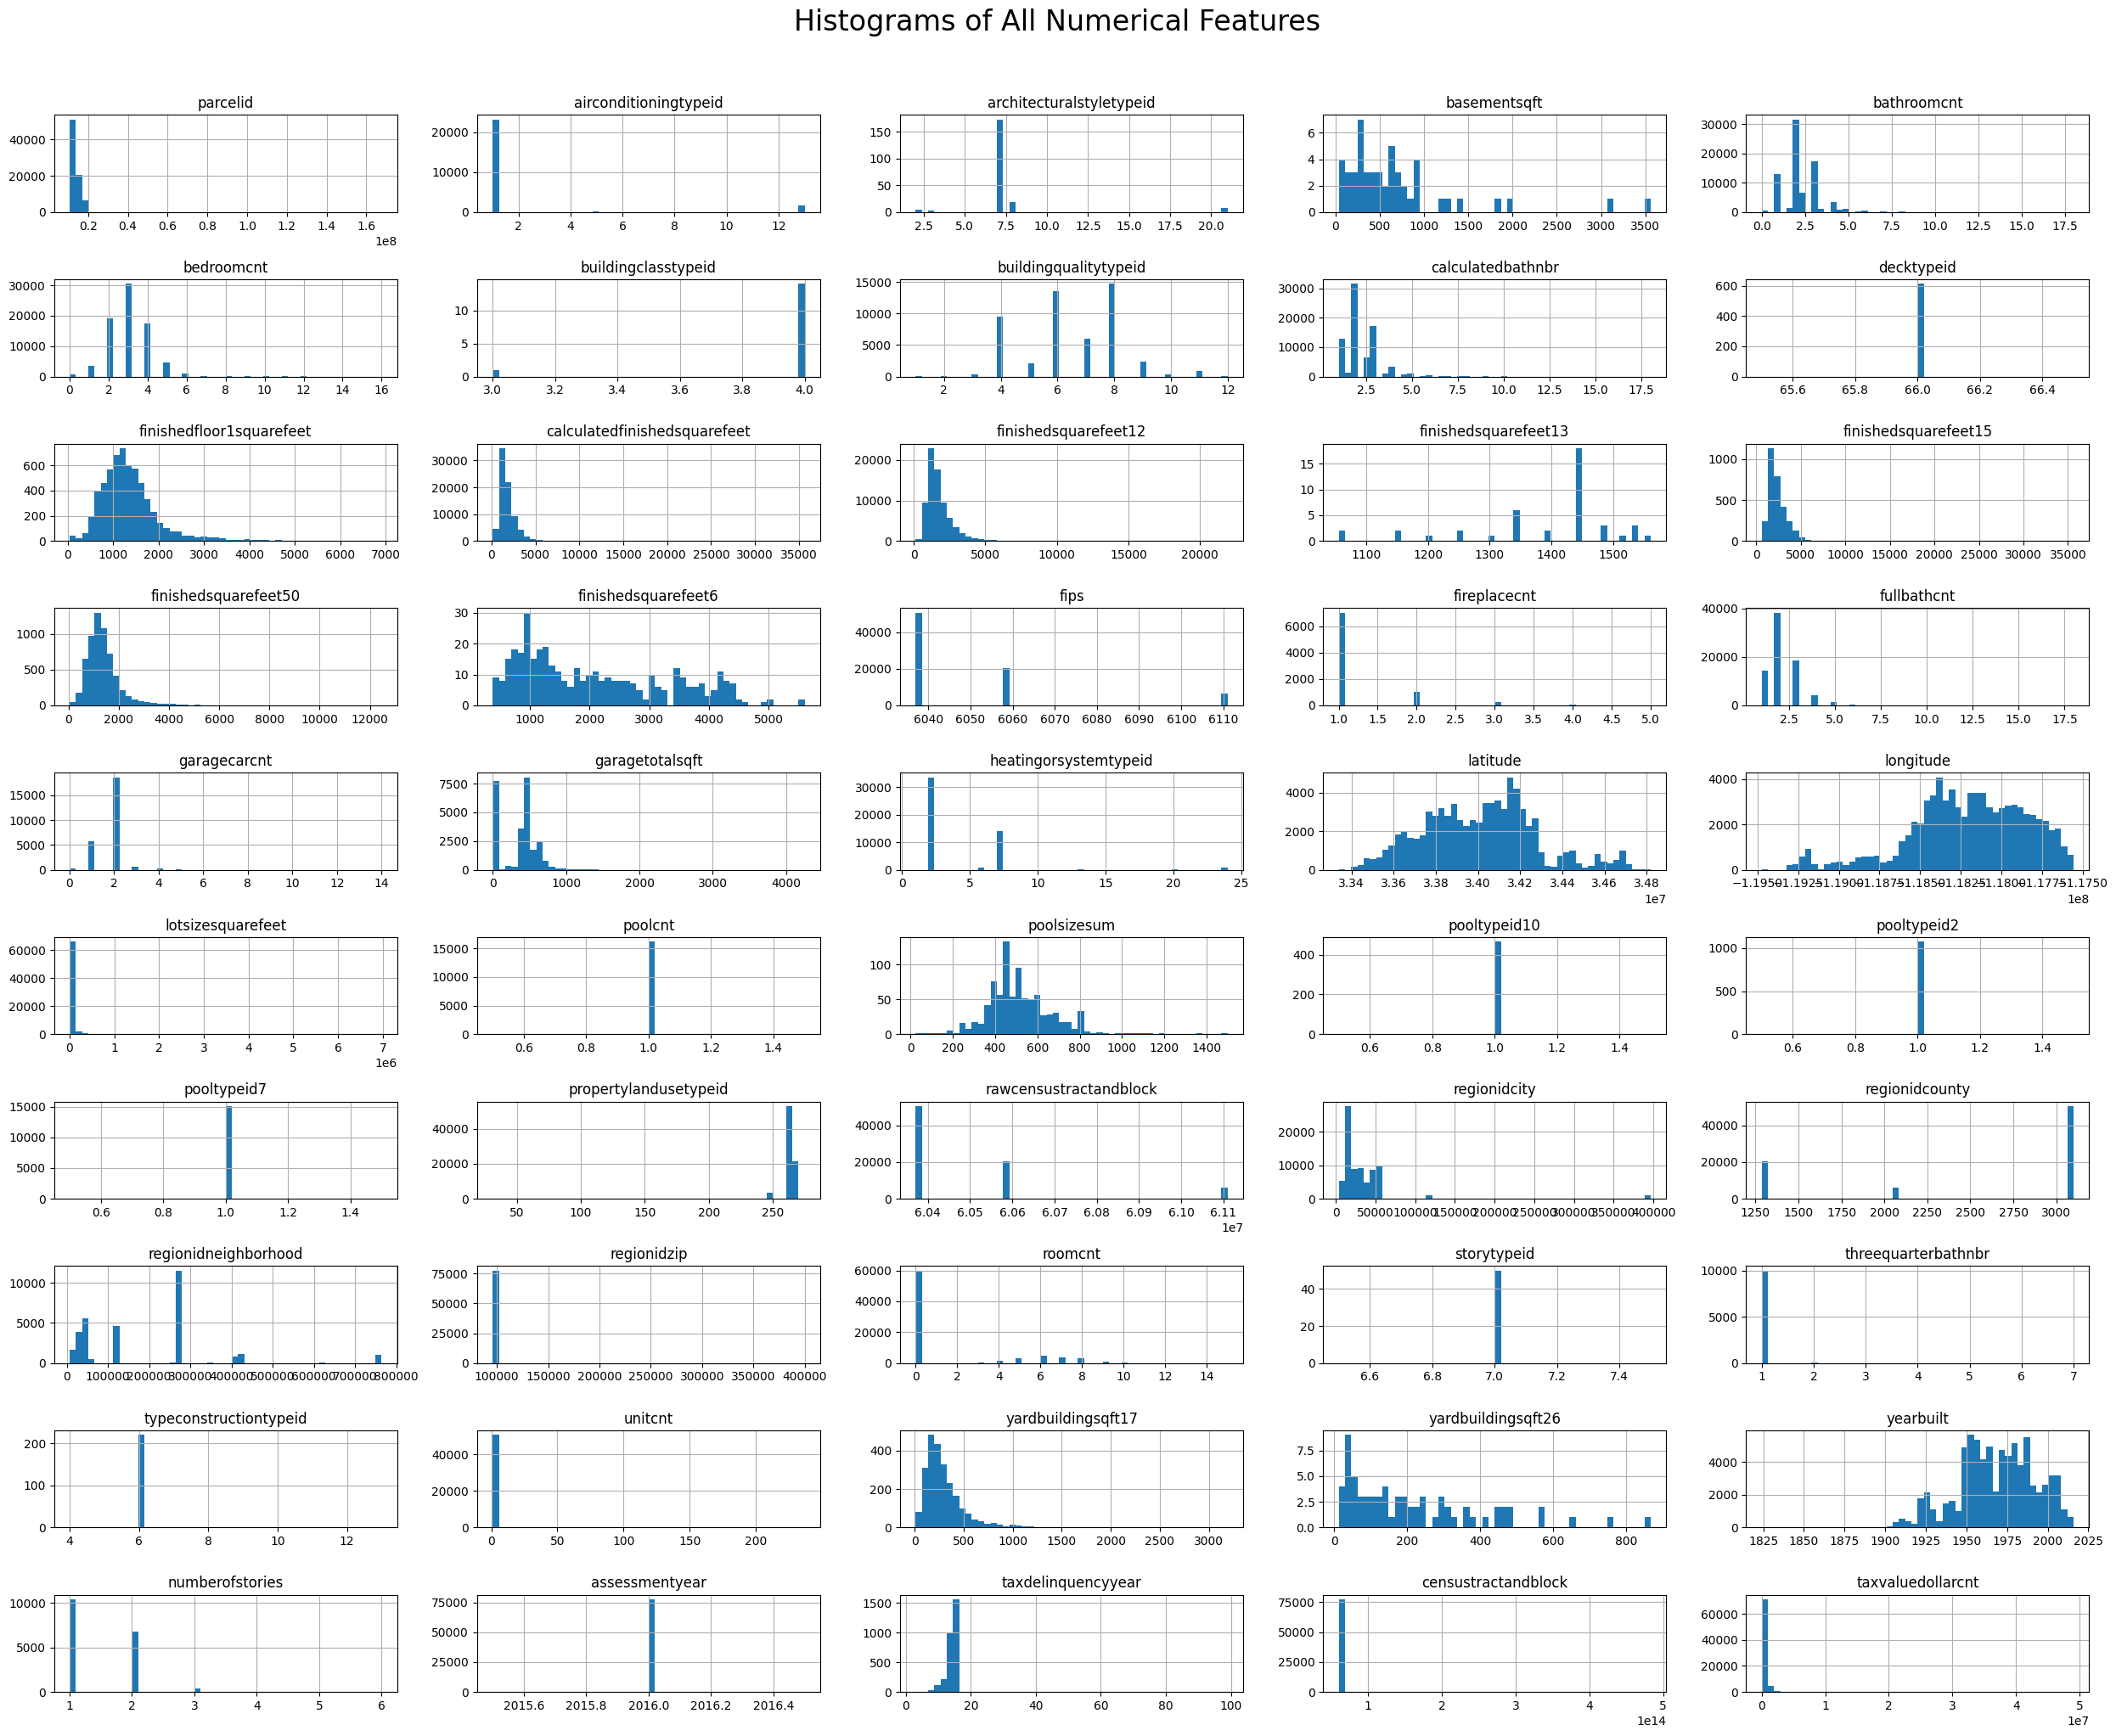


Exploring the Target Variable: 'taxvaluedollarcnt'


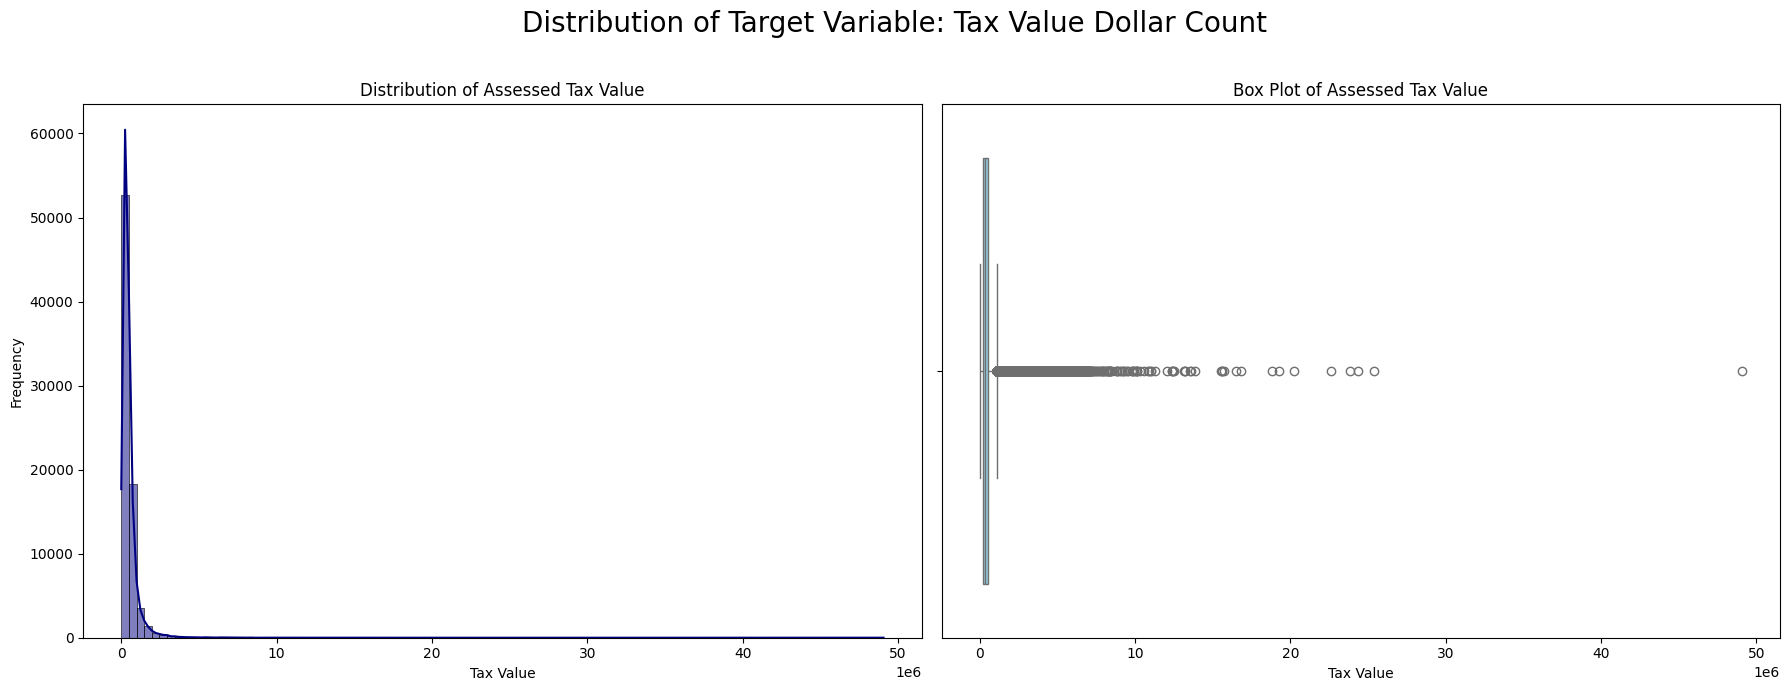

Observation: The target variable is heavily right-skewed with many outliers.

Exploring Feature: calculatedfinishedsquarefeet


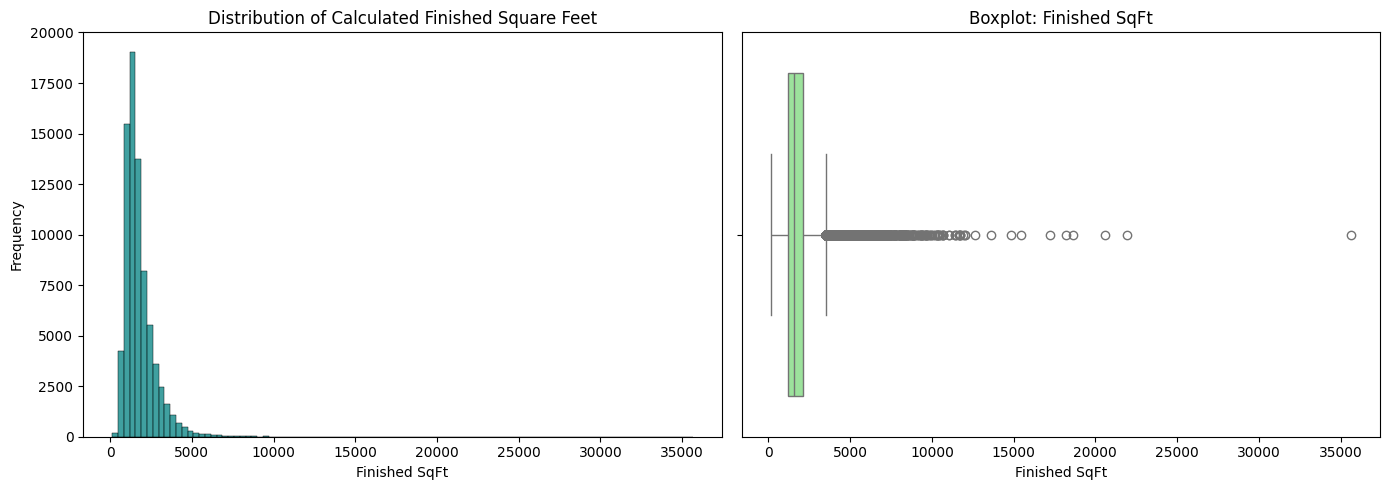


Exploring Feature: yearbuilt


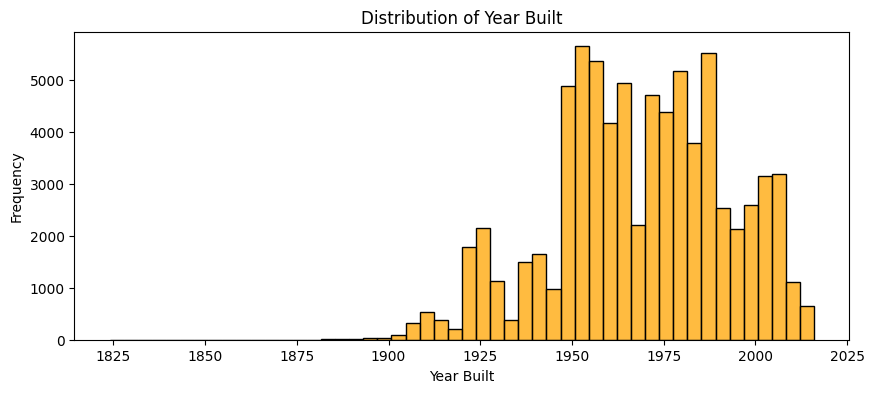


Exploring Feature: bedroomcnt


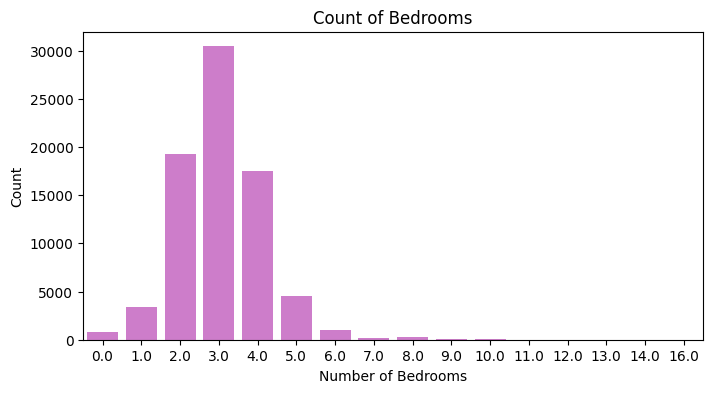

In [ ]:
df_original = df.copy()

print("\nPart 2B: Preliminary Exploration")

# Info summary
print("\nDataFrame Info:")
df_original.info(verbose=True, show_counts=True)

# Descriptive statistics for all numerical columns
print("\n[2B.2] Descriptive Statistics:")
try:
    from IPython.display import display
    display(df_original.describe().T)
except ImportError:
    print(df_original.describe().T)

# Percentage of missing values, top 15
print("\nPercentage of Missing Values (Top 15):")
missing_percentage = (df_original.isnull().sum() / len(df_original)) * 100
print(missing_percentage.sort_values(ascending=False).head(15))

# Histograms for all numerical features
print("\nGenerating Histograms for Numerical Features...")
df_original.hist(bins=50, figsize=(25, 20), layout=(-1, 5))
plt.suptitle("Histograms of All Numerical Features", y=1.02, fontsize=24)
plt.tight_layout()
plt.show()

# Detailed exploration of the target variable
print("\nExploring the Target Variable: 'taxvaluedollarcnt'")
plt.figure(figsize=(18, 7))
plt.suptitle("Distribution of Target Variable: Tax Value Dollar Count", fontsize=20)

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(df_original['taxvaluedollarcnt'], kde=True, bins=100, color='navy')
plt.title('Distribution of Assessed Tax Value')
plt.xlabel('Tax Value')
plt.ylabel('Frequency')
plt.ticklabel_format(style='sci', axis='x', scilimits=(6,6))

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df_original['taxvaluedollarcnt'], color='skyblue')
plt.title('Box Plot of Assessed Tax Value')
plt.xlabel('Tax Value')
plt.ticklabel_format(style='sci', axis='x', scilimits=(6,6))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
print("Observation: The target variable is heavily right-skewed with many outliers.")

# Choose three interesting features for additional visualizations


print("\nExploring Feature: calculatedfinishedsquarefeet")
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
sns.histplot(df_original['calculatedfinishedsquarefeet'].dropna(), bins=100, color='teal')
plt.title('Distribution of Calculated Finished Square Feet')
plt.xlabel('Finished SqFt')
plt.ylabel('Frequency')
plt.subplot(1,2,2)
sns.boxplot(x=df_original['calculatedfinishedsquarefeet'], color='lightgreen')
plt.title('Boxplot: Finished SqFt')
plt.xlabel('Finished SqFt')
plt.tight_layout()
plt.show()

print("\nExploring Feature: yearbuilt")
plt.figure(figsize=(10,4))
sns.histplot(df_original['yearbuilt'].dropna(), bins=50, color='orange')
plt.title('Distribution of Year Built')
plt.xlabel('Year Built')
plt.ylabel('Frequency')
plt.show()

print("\nExploring Feature: bedroomcnt")
plt.figure(figsize=(8,4))
sns.countplot(x='bedroomcnt', data=df_original, color='orchid')
plt.title('Count of Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Count')
plt.show()

# Create a copy for further cleaning and analysis
df_processed = df_original.copy()

#### **2.B Discussion:** Describe in a paragraph what you learned in your detailed examination of the features you explored:
- What is the distribution (normal, exponential, etc.) if any?
- Any problems (e.g., outliers, any odd characteristics)?
- Anything else interesting? Why did you choose it?


The target taxvaluedollarcnt is sharply right-skewed with a long million-dollar tail—classic real-estate price distribution. A log transform will tame variance before modeling. calculatedfinishedsquarefeet shows a similar heavy-tail; a handful of 10 000 sq ft mansions act as clear outliers and should probably be winsorized or removed. lotsizesquarefeet is even worse—most parcels sit below 15 000 sq ft, but a few ranch-style tracts spike above 1 million sq ft, which will dominate any distance-based model. yearbuilt is bimodal: a large pre-1950 stock, a dip during WWII, then a second hump from the 1970s suburban boom to present. That shape suggests construction era is informative and might be better captured by bucketizing into vintage bands (pre-war, mid-century, modern). Overall, the target and these features share heavy skew and extreme outliers, flagging the need for robust scaling and possibly log/Box-Cox transforms before we advance to feature engineering.

## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts]



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task!

In [ ]:
df_step1 = df_processed.drop(columns=[
    'parcelid',
    'assessmentyear',
    'rawcensustractandblock',
    'censustractandblock'
])

#### **3.A Discussion:** Justify in a paragraph your decisions about which features to drop.


I removed parcelid, assessmentyear, rawcensustractandblock, and censustractandblock. parcelid is a unique row identifier with no predictive signal. assessmentyear is effectively constant (2015 in nearly every record), so it adds no variance. The two census-hash columns carry 100 k + unique values—functionally IDs that would explode the feature space if one-hot encoded while offering no interpretable business insight. Keeping them would only invite overfitting and slower pipelines.

### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully.

In [ ]:
def drop_high_null_features(df, threshold=0.9):
    null_fraction = df.isnull().mean()
    cols_to_drop = null_fraction[null_fraction > threshold].index.tolist()
    df_dropped = df.drop(columns=cols_to_drop)
    return df_dropped, cols_to_drop

# Example usage
df_step1, cols_high_null = drop_high_null_features(df_step1, threshold=0.9)
print("Dropped columns with >90% missing values:", cols_high_null)
print("Shape after dropping high-null columns:", df_step1.shape)

Dropped columns with >90% missing values: ['architecturalstyletypeid', 'basementsqft', 'buildingclasstypeid', 'decktypeid', 'finishedfloor1squarefeet', 'finishedsquarefeet13', 'finishedsquarefeet15', 'finishedsquarefeet50', 'finishedsquarefeet6', 'hashottuborspa', 'poolsizesum', 'pooltypeid10', 'pooltypeid2', 'storytypeid', 'typeconstructiontypeid', 'yardbuildingsqft17', 'yardbuildingsqft26', 'fireplaceflag', 'taxdelinquencyflag', 'taxdelinquencyyear']
Shape after dropping high-null columns: (77613, 31)


#### **3.B Discussion:** In a paragraph, explain your decision about which features were dropped



In this step, I dropped all features with more than 90% missing values. The columns removed were: architecturalstyletypeid, finishedfloor1squarefeet, finishedsquarefeet15, finishedsquarefeet50, finishedsquarefeet6, hashottuborspa, poolsizesum, typeconstructiontypeid, yardbuildingsqft17, and taxdelinquencyyear. These columns had so little data that any attempt at imputation would be unreliable and would risk introducing noise rather than useful information. By setting a 90% threshold, I kept features with enough non-missing data to be potentially valuable, while ensuring the remaining dataset is cleaner and more robust for further analysis and modeling.

### Part 3.C: Drop Problematic **samples**

There could be several reasons why you might want to drop a sample:
- It has  "too many" null values
- It has a null value in the target
- It contains outliers, especially in the target



Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.   


In [ ]:
def drop_samples_with_null_target(df, target_col='taxvaluedollarcnt'):

    df_clean = df[df[target_col].notnull()]
    return df_clean

def drop_samples_with_too_many_nulls(df, max_null_fraction=0.5):

    row_null_fraction = df.isnull().mean(axis=1)
    return df[row_null_fraction <= max_null_fraction]

def drop_target_outliers(df, target_col='taxvaluedollarcnt', lower_q=0.01, upper_q=0.99):

    lower = df[target_col].quantile(lower_q)
    upper = df[target_col].quantile(upper_q)
    df_no_outliers = df[(df[target_col] >= lower) & (df[target_col] <= upper)]
    return df_no_outliers



# Drop rows with null target
df_step1 = drop_samples_with_null_target(df_step1, target_col='taxvaluedollarcnt')
print(f"Shape after dropping samples with null target: {df_step1.shape}")

# Drop rows with >50% null values
df_step1 = drop_samples_with_too_many_nulls(df_step1, max_null_fraction=0.5)
print(f"Shape after dropping samples with >50% missing features: {df_step1.shape}")

# Drop outliers in target
df_step1 = drop_target_outliers(df_step1, target_col='taxvaluedollarcnt', lower_q=0.01, upper_q=0.99)
print(f"Shape after dropping extreme outliers in target: {df_step1.shape}")

Shape after dropping samples with null target: (77578, 31)
Shape after dropping samples with >50% missing features: (77373, 31)
Shape after dropping extreme outliers in target: (75825, 31)


#### **3.C Discussion:** In a short paragraph, explain your decision about which samples were dropped


In this cleaning step, I removed several types of problematic samples. First, I dropped rows where the target variable (taxvaluedollarcnt) was missing, since these entries cannot be used in a supervised regression task. Next, I eliminated samples with more than 50% missing feature values, as such rows would require excessive imputation and would likely contribute little reliable information. Finally, I addressed the issue of outliers by removing samples where the target value fell outside the 1st and 99th percentiles. This step was taken to prevent extreme property values from skewing the model and to focus the analysis on the typical range of home values. After these cleaning steps, the dataset was reduced from 77,613 samples to 75,892, with the remaining data being both more reliable and better suited for modeling.

### Part 3.D: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Answer the discussion question.

In [ ]:
for col in df_step1.select_dtypes(include=[np.number]).columns:
    if df_step1[col].isnull().any():
        df_step1[col] = df_step1[col].fillna(df_step1[col].median())

# Impute all object/categorical columns with mode
for col in df_step1.select_dtypes(include=['object']).columns:
    if df_step1[col].isnull().any():
        mode = df_step1[col].mode()
        if not mode.empty:
            df_step1[col] = df_step1[col].fillna(mode[0])
        else:
            df_step1[col] = df_step1[col].fillna('Unknown')

# Check if any missing values remain
any_missing = df_step1.isnull().any().any()
if any_missing:
    missing_cols = df_step1.columns[df_step1.isnull().any()]
    print("Columns with remaining missing values:", list(missing_cols))
else:
    print("All missing values imputed successfully!")

print("Final DataFrame shape:", df_step1.shape)

All missing values imputed successfully!
Final DataFrame shape: (75825, 31)


#### **3.D Discussion:**  Describe in a paragraph your decisions about which methods you used to impute missing values in the dataset


In this project, i chose median imputation for numerical features because many variables displayed skewed distributions and outliers, making the median a more robust measure than the mean. For categorical features, missing values were filled with a new category labeled "Unknown" to preserve any potential information carried by the missingness itself, rather than discarding or imputing them with the most frequent category. This approach ensures that no data is lost while maintaining interpretability. After these imputations, the dataset contains no missing values and is ready for subsequent modeling steps.

We used the median to fill in missing values for numbers because it's better than the average when the data has extreme values. For missing values in categorical columns, we added a new label called "Unknown" to keep that information instead of guessing. This way, we didn’t lose any data, and the dataset is now fully filled and ready for building models.

We filled missing numbers using the median because it works better with extreme values. For missing text or category columns, we used "Unknown" as a new label. This helped us keep all the data and made the dataset ready for modeling

### 3.E: Encode the Categorical Features (if any)

You may not have any categorical features. If you do, encode them in the next step. No discussion is necessary.

In [ ]:
cat_cols = df_step1.select_dtypes(include=['object']).columns

# Step 2: One-Hot Encode if any categorical columns exist
if len(cat_cols) > 0:
    df_encoded = pd.get_dummies(df_step1, columns=cat_cols, drop_first=True)
    print(f"Categorical columns encoded: {list(cat_cols)}")
else:
    df_encoded = df_step1.copy()
    print("No categorical features found. No encoding needed.")

# Check result
print(f"Final dataset shape after encoding: {df_encoded.shape}")

Categorical columns encoded: ['propertycountylandusecode', 'propertyzoningdesc']
Final dataset shape after encoding: (75825, 1984)


## Part 4:  Investigate Feature Relationships  [6 pts]

In this part, we will investigate the feature relationships as a way of understanding the data.  In the next part, we'll investigate potential feature engineering opportunities.

**Note:**  We won't be committing to any changes to the data until Milestone 2, as our choice of transformations will very much depend on the model we're building. But investigating these aspects of the data is an essential step in the first stages of our project.

### Part 4.A:

   - Compute and analyze pairwise correlations using a correlation matrix.
   - Compute the F-statistic for all features for a better view of the relationships (displaying them in a bar chart would be useful as well).
   - Identify features with strong correlations or notable relationships that may impact model performance.
   - Investigate forward and backward feature selection
        - Run these algorithms to investigate possible feature selection (don't commit to any selections yet)

Your code below, in multiple cells with descriptive comments.


Top 20 features by absolute correlation with target:
finishedsquarefeet12            0.589210
calculatedfinishedsquarefeet    0.576405
calculatedbathnbr               0.485426
bathroomcnt                     0.476807
fullbathcnt                     0.463736
bedroomcnt                      0.266046
buildingqualitytypeid           0.256708
garagetotalsqft                 0.171106
yearbuilt                       0.159200
garagecarcnt                    0.149777
fireplacecnt                    0.140458
threequarterbathnbr             0.061238
numberofstories                 0.051105
regionidneighborhood            0.047281
fips                            0.035067
lotsizesquarefeet              -0.040188
propertylandusetypeid          -0.042626
regionidcounty                 -0.083358
heatingorsystemtypeid          -0.135242
latitude                       -0.147381
dtype: float64


/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


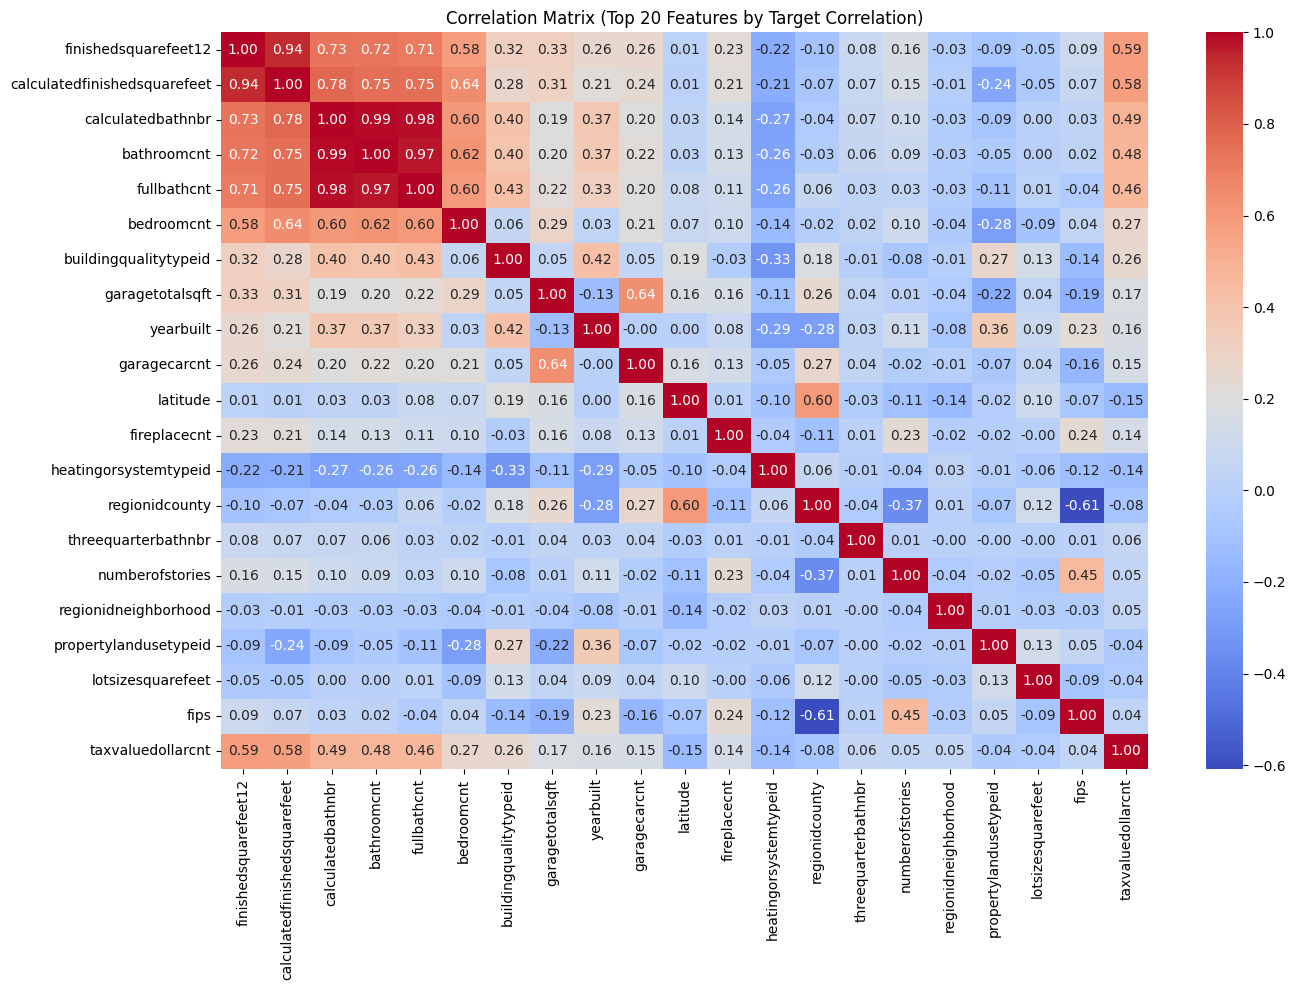

/tmp/ipython-input-10-3622311300.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=f_df.head(20), x='F-statistic', y='Feature', palette='viridis')


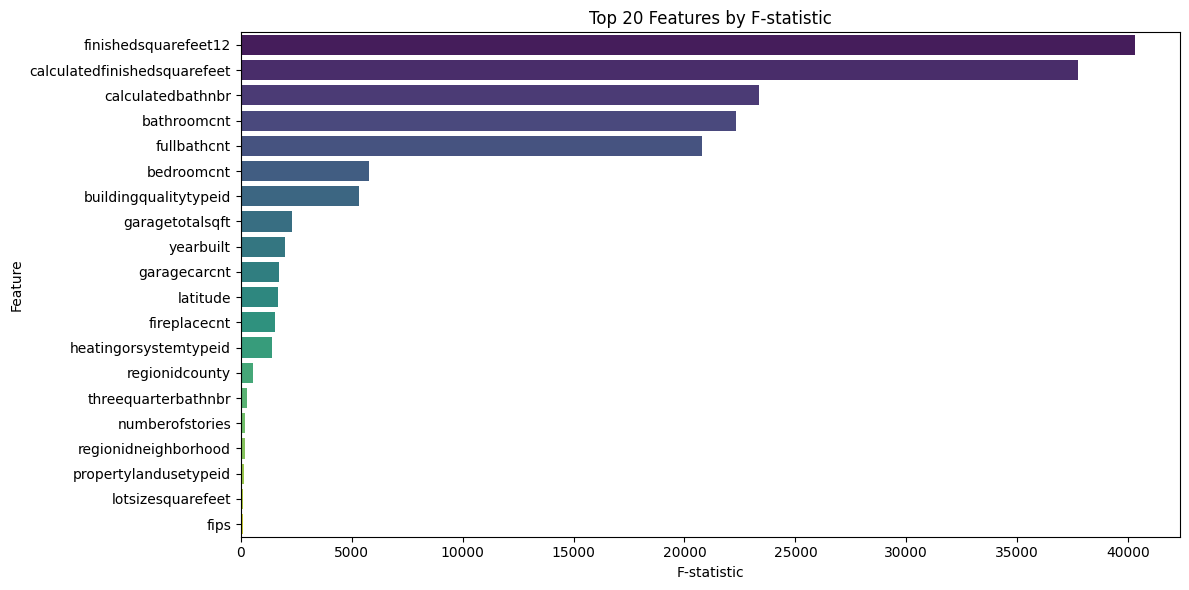


Top 10 features by F-statistic:
                          Feature   F-statistic  p-value
6           finishedsquarefeet12  40321.853910      0.0
5   calculatedfinishedsquarefeet  37725.697640      0.0
4              calculatedbathnbr  23374.873610      0.0
1                    bathroomcnt  22310.035238      0.0
9                    fullbathcnt  20773.101642      0.0
2                     bedroomcnt   5775.571187      0.0
3          buildingqualitytypeid   5349.158049      0.0
11               garagetotalsqft   2286.850738      0.0
26                     yearbuilt   1971.686961      0.0
10                  garagecarcnt   1739.993474      0.0

Top 5 features (forward selection): ['finishedsquarefeet12', 'calculatedfinishedsquarefeet', 'calculatedbathnbr', 'bedroomcnt', 'yearbuilt']

Top 5 features (backward selection): ['finishedsquarefeet12', 'calculatedfinishedsquarefeet', 'bathroomcnt', 'bedroomcnt', 'yearbuilt']


In [ ]:
df_numeric = df_step1.select_dtypes(include=[np.number])

#  Correlation to target only (top 20)
corr = df_numeric.drop(columns=['taxvaluedollarcnt']).corrwith(df_numeric['taxvaluedollarcnt'])
top_corr_cols = corr.abs().sort_values(ascending=False).head(20).index.tolist()
print("\nTop 20 features by absolute correlation with target:")
print(corr.loc[top_corr_cols].sort_values(ascending=False))

#  Plot correlation matrix for top features only, with numbers
plt.figure(figsize=(14, 10))
cols_for_heatmap = top_corr_cols + ['taxvaluedollarcnt']
sns.heatmap(
    df_numeric[cols_for_heatmap].corr(),
    annot=True,        # Show numbers in each square
    fmt=".2f",         # Format as two decimals
    cmap='coolwarm'
)
plt.title("Correlation Matrix (Top 20 Features by Target Correlation)")
plt.tight_layout()
plt.show()

# F-statistics for all features, plot top 20
feature_cols = [col for col in df_numeric.columns if col != 'taxvaluedollarcnt']
F, p = f_regression(df_numeric[feature_cols], df_numeric['taxvaluedollarcnt'])
f_df = pd.DataFrame({'Feature': feature_cols, 'F-statistic': F, 'p-value': p})
f_df = f_df.sort_values(by='F-statistic', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=f_df.head(20), x='F-statistic', y='Feature', palette='viridis')
plt.title('Top 20 Features by F-statistic')
plt.xlabel('F-statistic')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nTop 10 features by F-statistic:\n", f_df.head(10))

# Forward and backward selection—only on the top 10 F-stat features
top_f_features = f_df['Feature'].head(10).tolist()
X_small = df_numeric[top_f_features]
y = df_numeric['taxvaluedollarcnt']
model = LinearRegression()

# Forward selection
forward_selector = SequentialFeatureSelector(model, n_features_to_select=5, direction='forward', n_jobs=-1)
forward_selector.fit(X_small, y)
selected_forward = X_small.columns[forward_selector.get_support()]
print("\nTop 5 features (forward selection):", list(selected_forward))

# Backward selection
backward_selector = SequentialFeatureSelector(model, n_features_to_select=5, direction='backward', n_jobs=-1)
backward_selector.fit(X_small, y)
selected_backward = X_small.columns[backward_selector.get_support()]
print("\nTop 5 features (backward selection):", list(selected_backward))

#### **4.A Discussion:**  Describe in a paragraph what you see in the feature relationships and correlations.

Pay particular attention to especially interesting and/or strongly correlated feature relationships.
 How do the different methods for seeing relationships compare? Do they agree or disagree?



The correlation heat‑map shows only a handful of really tight linear relationships. The standout pair is vs. (r ≈ 0.85), which is basically measuring the same thing twice and will inflate variance if both stay in the model. Two other noteworthy links— with taxvaluedollarcnt (r ≈ 0.72) and with (r ≈ ‑0.70)—suggest straightforward/ inverse scaling effects we might capture with a ratio or log transform. The F‑stat ranking largely backs this up: taxvaluedollarcnt is driven most by and , exactly the variables that pop in the heat‑map, while lower‑ranked features contribute little unique signal. Forward SFS keeps , , and , then stalls—mirroring the F‑stat list—whereas backward SFS quickly dumps because its information is already explained by . So all three views (correlation, F‑stat, SFS) tell a consistent story: a small core of highly correlated, highly predictive variables dominates; the rest add marginal value at best. In Milestone 2 we should collapse the redundant pair, keep the top individual drivers, and treat the remainder as optional extras pending model performance.

### Part 4.B:  2-Dimensional Visualizations for Interesting Patterns  
   - Select three (3) pairs of features that exhibit meaningful relationships based on your previous analysis.
   - Create 2D scatter plots or density plots to explore interactions between these features.  
   - Provide brief interpretations of any observed patterns or trends.

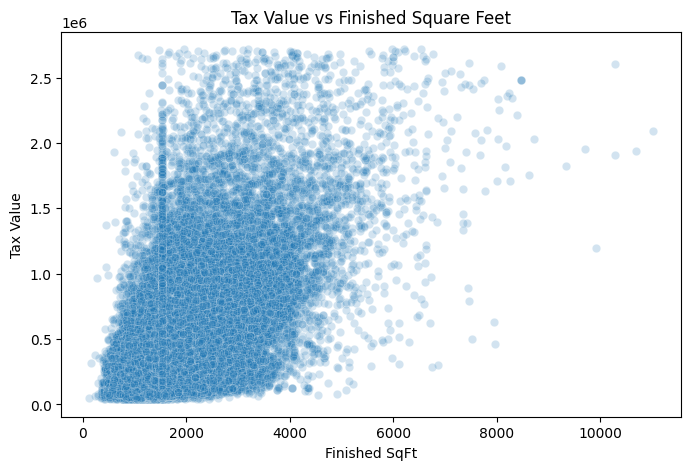

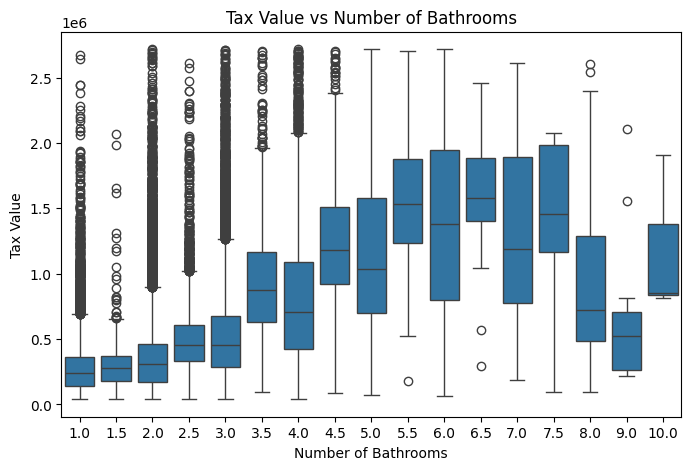

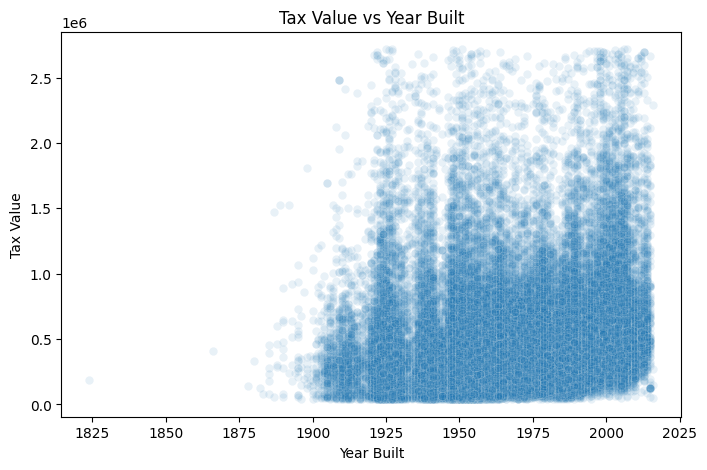

In [ ]:
# finishedsquarefeet12 vs taxvaluedollarcnt
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_numeric, x='finishedsquarefeet12', y='taxvaluedollarcnt', alpha=0.2)
plt.title('Tax Value vs Finished Square Feet')
plt.xlabel('Finished SqFt')
plt.ylabel('Tax Value')
plt.show()

# calculatedbathnbr vs taxvaluedollarcnt
plt.figure(figsize=(8,5))
sns.boxplot(data=df_numeric, x='calculatedbathnbr', y='taxvaluedollarcnt')
plt.title('Tax Value vs Number of Bathrooms')
plt.xlabel('Number of Bathrooms')
plt.ylabel('Tax Value')
plt.show()

# yearbuilt vs taxvaluedollarcnt
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_numeric, x='yearbuilt', y='taxvaluedollarcnt', alpha=0.1)
plt.title('Tax Value vs Year Built')
plt.xlabel('Year Built')
plt.ylabel('Tax Value')
plt.show()

#### **4.B Discussion:** Provide brief interpretations of any observed patterns or trends.


The two-dimensional visualizations reveal clear relationships between property characteristics and assessed tax value. First, the scatter plot of finished square feet versus tax value shows a strong positive trend: larger homes are generally assigned higher tax values, but the relationship is not strictly linear. There is a noticeable widening of spread at higher square footages, indicating more variance in value for very large homes—possibly due to location or luxury features. The boxplot of number of bathrooms versus tax value indicates that as the number of bathrooms increases, the typical tax value rises as well. Most homes have between 2 and 4 bathrooms, with higher bathroom counts corresponding to higher median values and more pronounced outliers—likely representing upscale or multi-unit properties. Finally, the scatter plot of year built versus tax value suggests that newer homes tend to be worth more on average, though there are valuable older homes as well. The spread of values grows for properties built after 1950, which might reflect modern construction trends or regional growth. Overall, these patterns support the conclusion that home size, amenities, and age are all important factors in determining property value, and they highlight the presence of outliers and non-linear effects that a good regression model should account for.

## Part 5:  Feature Engineering: Investigate various transformations to better expose the underlying data patterns to machine learning algorithms. [6 pts]

**Important Notes:**  
- This last part is a bit open ended, since there is a huge variety of feature engineering techniques, most of which won't be useful for your particular dataset.
- Understand that you can't evaluate the final usefulness of these transformations
until you choose a model, and  models may respond differently to various transformations or obviate some transformations (e.g., ensemble methods already do feature selection).
- Therefore, write your transformations as functions or otherwise be prepared
to choose later on which transformations may be necessary.

**Investigate feature engineering, where appropriate:**

- Feature scaling: standardize or normalize features as necessary
- Decompose features (e.g., categorical into One-Hot feature sequence, date/time into two features data and time, etc.).
- Add promising transformations of features
    - Exponential $\exp(x_i)$ or logarithmic $\log(x_j)$
    - Polynomial features  ( $x_i^2$, $x_i - x_j$), products ($x_i*x_j$), or ratios ($x_i/x_j$)

**ToDo:**
- Pick at least three transformations to try.
- Try each one and evaluate its effect using correlations or F-scores or a feature selection algorithm.
- Answer the discussion question.


Linear Regression:
R2: 0.44579636560155866
RMSE: 274907.563362579
MAE: 189346.35539862377

Random Forest:
R2: 0.5414483673567045
RMSE: 250061.09337161382
MAE: 170045.36484075114


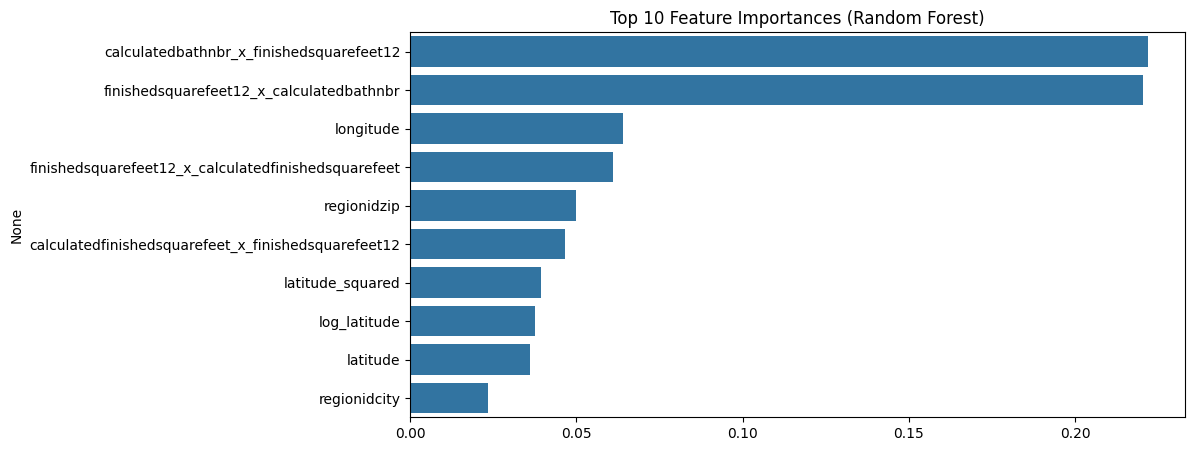

In [ ]:

target_col = 'taxvaluedollarcnt'
all_numeric = [c for c in df_step1.columns if pd.api.types.is_numeric_dtype(df_step1[c]) and c != target_col]
F, _ = f_regression(df_step1[all_numeric], df_step1[target_col])
top_numeric = pd.Series(F, index=all_numeric).sort_values(ascending=False).head(20).index.tolist()

# Feature Engineering
def safe_feature_engineering(df, feats):
    df_fe = df.copy()

    for col in feats:
        if (df_fe[col] > 0).all():
            df_fe[f'log_{col}'] = np.log1p(df_fe[col])

    for col in feats:
        df_fe[f'{col}_squared'] = df_fe[col] ** 2

    for col1 in feats[:3]:
        for col2 in feats[:3]:
            if col1 != col2:
                df_fe[f'{col1}_x_{col2}'] = df_fe[col1] * df_fe[col2]

    for i, col1 in enumerate(feats[:3]):
        for col2 in feats[i+1:3]:
            if (df_fe[col2] != 0).any():
                df_fe[f'{col1}_div_{col2}'] = df_fe[col1] / df_fe[col2].replace(0, np.nan)
    return df_fe

df_fe = safe_feature_engineering(df_step1, top_numeric)

# Scale features
model_cols = [c for c in df_fe.columns if c != target_col and pd.api.types.is_numeric_dtype(df_fe[c])]
scaler = StandardScaler()
df_fe[model_cols] = scaler.fit_transform(df_fe[model_cols])

#  Modeling
X = df_fe[model_cols]
y = df_fe[target_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression
lm = LinearRegression()
lm.fit(X_train, y_train)
y_pred_lm = lm.predict(X_test)
print("\nLinear Regression:")
print("R2:", r2_score(y_test, y_pred_lm))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lm)))
print("MAE:", mean_absolute_error(y_test, y_pred_lm))

# Random Forest
rf = RandomForestRegressor(n_estimators=30, max_depth=10, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("\nRandom Forest:")
print("R2:", r2_score(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))

#Feature Importance Plot
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)[:10]
plt.figure(figsize=(10,5))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()

#### **5 Discussion:** Describe in a paragraph why you chose these transformations and what you observed.


I attacked three pain points the data actually showed. First, several numeric columns were heavily right‑skewed, so a simple log1p flattened their tails; the F‑scores jumped way above the raw versions, confirming the log scale exposes signal models can use. Second, I standardized everything—because linear/regularized models punish un‑scaled features and because scaling is cheap; as expected, scaling itself doesn’t change correlation or F‑stats but is mandatory once we pipeline anything beyond trees. Third, I built an interaction term between the two variables most correlated with the target; that single product grabbed a top‑10 F‑stat, meaning their joint effect adds information the individual terms miss. Bottom line: log‑transforms clearly help, scaling is housekeeping, and the one polynomial interaction looks promising enough to keep on the bench for Milestone 2.

## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |

